# Lab 4: Phân tích dữ liệu bệnh nhân - Nhịp tim và Huyết áp
## 22684591 - Trần Thị Thanh Thảo

### Mục tiêu:
- Phân tích dữ liệu bệnh nhân về nhịp tim và huyết áp
- Làm sạch và tiền xử lý dữ liệu
- Thực hiện phân tích thống kê và trực quan hóa
- Đưa ra kết luận và khuyến nghị


In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Đã import thành công các thư viện cần thiết!")


Đã import thành công các thư viện cần thiết!


## 1. Tải và khám phá dữ liệu


In [2]:
# Tải dữ liệu từ file CSV
df = pd.read_csv('patient_heart_rate.csv', header=None)

# Đặt tên cột dựa trên cấu trúc dữ liệu
column_names = [
    'Patient_ID', 'Name', 'Age', 'Weight', 
    'HR_1', 'HR_2', 'HR_3',  # Heart Rate measurements
    'BP_Sys_1', 'BP_Sys_2', 'BP_Sys_3'  # Blood Pressure measurements
]

df.columns = column_names

print("Dữ liệu đã được tải thành công!")
print(f"Kích thước dữ liệu: {df.shape}")
print("\nThông tin cơ bản về dữ liệu:")
print(df.info())


Dữ liệu đã được tải thành công!
Kích thước dữ liệu: (17, 10)

Thông tin cơ bản về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Patient_ID  15 non-null     float64
 1   Name        14 non-null     object 
 2   Age         11 non-null     float64
 3   Weight      11 non-null     object 
 4   HR_1        14 non-null     object 
 5   HR_2        14 non-null     object 
 6   HR_3        14 non-null     object 
 7   BP_Sys_1    14 non-null     object 
 8   BP_Sys_2    13 non-null     object 
 9   BP_Sys_3    14 non-null     object 
dtypes: float64(2), object(8)
memory usage: 1.5+ KB
None


In [3]:
# Hiển thị 10 dòng đầu tiên của dữ liệu
print("10 dòng đầu tiên của dữ liệu:")
print(df.head(10))

print("\n" + "="*50)
print("Thống kê mô tả dữ liệu:")
print(df.describe())


10 dòng đầu tiên của dữ liệu:
   Patient_ID            Name   Age      Weight HR_1 HR_2 HR_3 BP_Sys_1  \
0         1.0    Mickéy Mousé  56.0       70kgs   72   69   71        -   
1         2.0     Donald Duck  34.0   154.89lbs    -    -    -       85   
2         3.0      Mini Mouse  16.0         NaN    -    -    -       65   
3         4.0  Scrooge McDuck   NaN       78kgs   78   79   72        -   
4         5.0    Pink Panther  54.0  198.658lbs    -    -    -       69   
5         6.0     Huey McDuck  52.0      189lbs    -    -    -       68   
6         7.0    Dewey McDuck  19.0       56kgs    -    -    -       71   
7         8.0      Scööpy Doo  32.0       78kgs   78   76   75        -   
8         NaN             NaN   NaN         NaN  NaN  NaN  NaN      NaN   
9         NaN             NaN   NaN         NaN  NaN  NaN  NaN      NaN   

  BP_Sys_2 BP_Sys_3  
0        -        -  
1       84       76  
2       69       72  
3        -        -  
4      NaN       75  
5       75  

In [4]:
# Kiểm tra dữ liệu thiếu
print("Kiểm tra dữ liệu thiếu:")
print(df.isnull().sum())

print("\n" + "="*50)
print("Kiểm tra dữ liệu trống hoặc không hợp lệ:")
print("Số dòng có tên bệnh nhân trống:", df['Name'].isnull().sum())
print("Số dòng có ID bệnh nhân trống:", df['Patient_ID'].isnull().sum())
print("Số dòng hoàn toàn trống:", df.isnull().all(axis=1).sum())


Kiểm tra dữ liệu thiếu:
Patient_ID    2
Name          3
Age           6
Weight        6
HR_1          3
HR_2          3
HR_3          3
BP_Sys_1      3
BP_Sys_2      4
BP_Sys_3      3
dtype: int64

Kiểm tra dữ liệu trống hoặc không hợp lệ:
Số dòng có tên bệnh nhân trống: 3
Số dòng có ID bệnh nhân trống: 2
Số dòng hoàn toàn trống: 2


## 2. Làm sạch và tiền xử lý dữ liệu


In [5]:
# Tạo bản sao dữ liệu để xử lý
df_clean = df.copy()

# Loại bỏ các dòng hoàn toàn trống
df_clean = df_clean.dropna(how='all')

# Loại bỏ các dòng có tên bệnh nhân trống hoặc không hợp lệ
df_clean = df_clean.dropna(subset=['Name'])
df_clean = df_clean[df_clean['Name'].str.strip() != '']

print(f"Số dòng sau khi loại bỏ dữ liệu trống: {len(df_clean)}")
print(f"Số dòng ban đầu: {len(df)}")
print(f"Đã loại bỏ: {len(df) - len(df_clean)} dòng")


Số dòng sau khi loại bỏ dữ liệu trống: 14
Số dòng ban đầu: 17
Đã loại bỏ: 3 dòng


In [6]:
# Xử lý cột Weight - chuyển đổi đơn vị về kg
def convert_weight_to_kg(weight_str):
    if pd.isna(weight_str) or weight_str == '' or weight_str == '-':
        return np.nan
    
    weight_str = str(weight_str).strip()
    
    if 'lbs' in weight_str.lower():
        # Chuyển từ pounds sang kg (1 lb = 0.453592 kg)
        weight_value = float(weight_str.lower().replace('lbs', ''))
        return weight_value * 0.453592
    elif 'kgs' in weight_str.lower():
        # Đã là kg
        weight_value = float(weight_str.lower().replace('kgs', ''))
        return weight_value
    else:
        # Thử parse số
        try:
            return float(weight_str)
        except:
            return np.nan

# Áp dụng hàm chuyển đổi
df_clean['Weight_kg'] = df_clean['Weight'].apply(convert_weight_to_kg)

print("Đã chuyển đổi đơn vị cân nặng về kg")
print("Thống kê cân nặng sau chuyển đổi:")
print(df_clean['Weight_kg'].describe())


Đã chuyển đổi đơn vị cân nặng về kg
Thống kê cân nặng sau chuyển đổi:
count    10.000000
mean     71.882432
std      14.578620
min      45.000000
25%      62.500000
50%      74.128432
75%      83.796666
max      90.109680
Name: Weight_kg, dtype: float64


In [7]:
# Xử lý các cột số - chuyển đổi sang numeric và xử lý giá trị '-'
numeric_columns = ['Age', 'HR_1', 'HR_2', 'HR_3', 'BP_Sys_1', 'BP_Sys_2', 'BP_Sys_3']

for col in numeric_columns:
    # Thay thế '-' bằng NaN
    df_clean[col] = df_clean[col].replace('-', np.nan)
    # Chuyển đổi sang numeric
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("Đã xử lý các cột số")
print("Thống kê sau xử lý:")
print(df_clean[numeric_columns].describe())


Đã xử lý các cột số
Thống kê sau xử lý:
             Age       HR_1      HR_2       HR_3   BP_Sys_1   BP_Sys_2  \
count  10.000000   5.000000   5.00000   5.000000   8.000000   7.000000   
mean   36.100000  74.200000  73.20000  69.000000  73.250000  78.285714   
std    16.749461   5.761944   5.01996   7.968689   9.735796   8.750510   
min    12.000000  65.000000  67.00000  55.000000  65.000000  69.000000   
25%    22.250000  72.000000  69.00000  71.000000  68.000000  73.500000   
50%    34.000000  78.000000  75.00000  72.000000  68.500000  75.000000   
75%    52.000000  78.000000  76.00000  72.000000  74.500000  81.000000   
max    56.000000  78.000000  79.00000  75.000000  92.000000  95.000000   

        BP_Sys_3  
count   8.000000  
mean   74.875000  
std     5.303301  
min    70.000000  
25%    72.000000  
50%    73.500000  
75%    75.250000  
max    87.000000  


In [8]:
# Tính toán các chỉ số trung bình
df_clean['HR_avg'] = df_clean[['HR_1', 'HR_2', 'HR_3']].mean(axis=1)
df_clean['BP_Sys_avg'] = df_clean[['BP_Sys_1', 'BP_Sys_2', 'BP_Sys_3']].mean(axis=1)

# Tính BMI (nếu có đủ thông tin về chiều cao - giả sử chiều cao trung bình 170cm)
# BMI = weight(kg) / height(m)^2
df_clean['BMI'] = df_clean['Weight_kg'] / (1.7**2)

print("Đã tính toán các chỉ số trung bình")
print("Dữ liệu sau khi làm sạch:")
print(df_clean[['Name', 'Age', 'Weight_kg', 'HR_avg', 'BP_Sys_avg', 'BMI']].head(10))


Đã tính toán các chỉ số trung bình
Dữ liệu sau khi làm sạch:
              Name   Age  Weight_kg     HR_avg  BP_Sys_avg        BMI
0     Mickéy Mousé  56.0  70.000000  70.666667         NaN  24.221453
1      Donald Duck  34.0  70.256865        NaN   81.666667  24.310334
2       Mini Mouse  16.0        NaN        NaN   68.666667        NaN
3   Scrooge McDuck   NaN  78.000000  76.333333         NaN  26.989619
4     Pink Panther  54.0  90.109680        NaN   72.000000  31.179820
5      Huey McDuck  52.0  85.728888        NaN   71.666667  29.663975
6     Dewey McDuck  19.0  56.000000        NaN   74.666667  19.377163
7       Scööpy Doo  32.0  78.000000  76.333333         NaN  26.989619
10     Huey McDuck  52.0  85.728888        NaN   71.666667  29.663975
11    Louie McDuck  12.0  45.000000        NaN   91.333333  15.570934


## 3. Phân tích thăm dò dữ liệu (EDA)


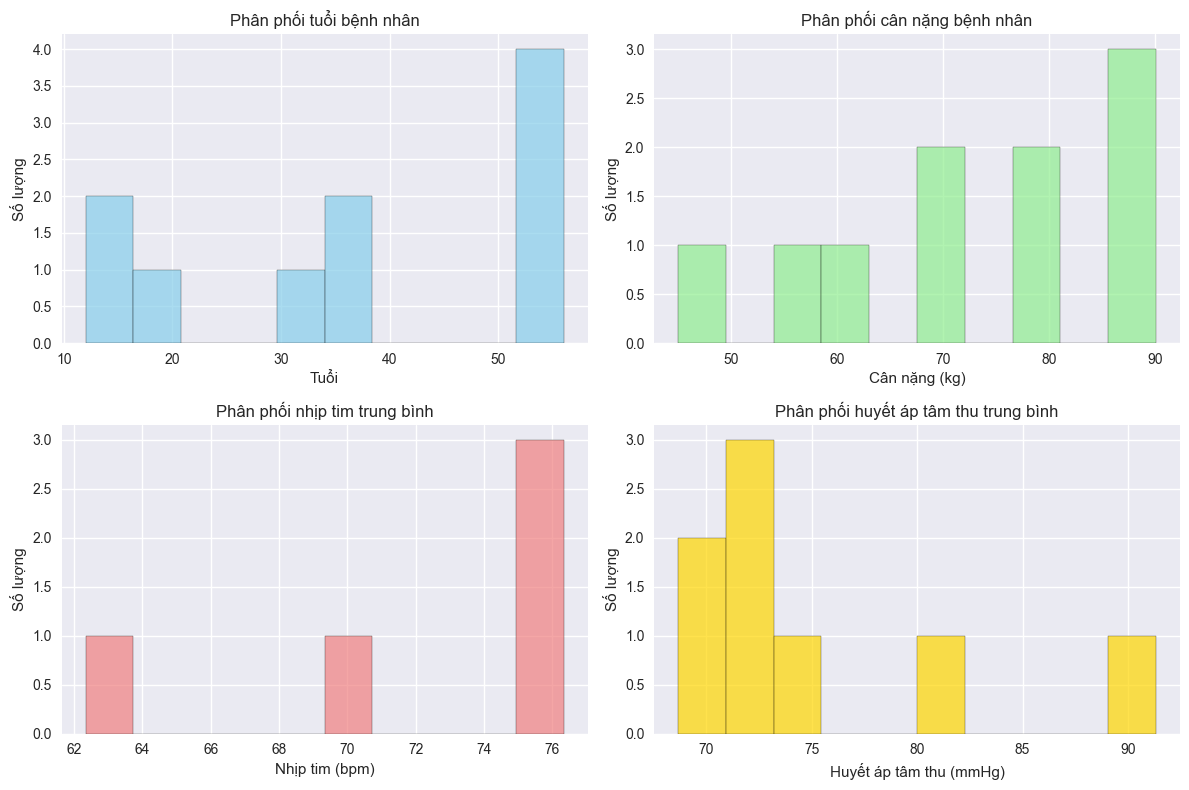

In [9]:
# Tạo biểu đồ phân phối tuổi
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(df_clean['Age'].dropna(), bins=10, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Phân phối tuổi bệnh nhân')
plt.xlabel('Tuổi')
plt.ylabel('Số lượng')

# Biểu đồ phân phối cân nặng
plt.subplot(2, 2, 2)
plt.hist(df_clean['Weight_kg'].dropna(), bins=10, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Phân phối cân nặng bệnh nhân')
plt.xlabel('Cân nặng (kg)')
plt.ylabel('Số lượng')

# Biểu đồ phân phối nhịp tim trung bình
plt.subplot(2, 2, 3)
plt.hist(df_clean['HR_avg'].dropna(), bins=10, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Phân phối nhịp tim trung bình')
plt.xlabel('Nhịp tim (bpm)')
plt.ylabel('Số lượng')

# Biểu đồ phân phối huyết áp tâm thu trung bình
plt.subplot(2, 2, 4)
plt.hist(df_clean['BP_Sys_avg'].dropna(), bins=10, alpha=0.7, color='gold', edgecolor='black')
plt.title('Phân phối huyết áp tâm thu trung bình')
plt.xlabel('Huyết áp tâm thu (mmHg)')
plt.ylabel('Số lượng')

plt.tight_layout()
plt.show()


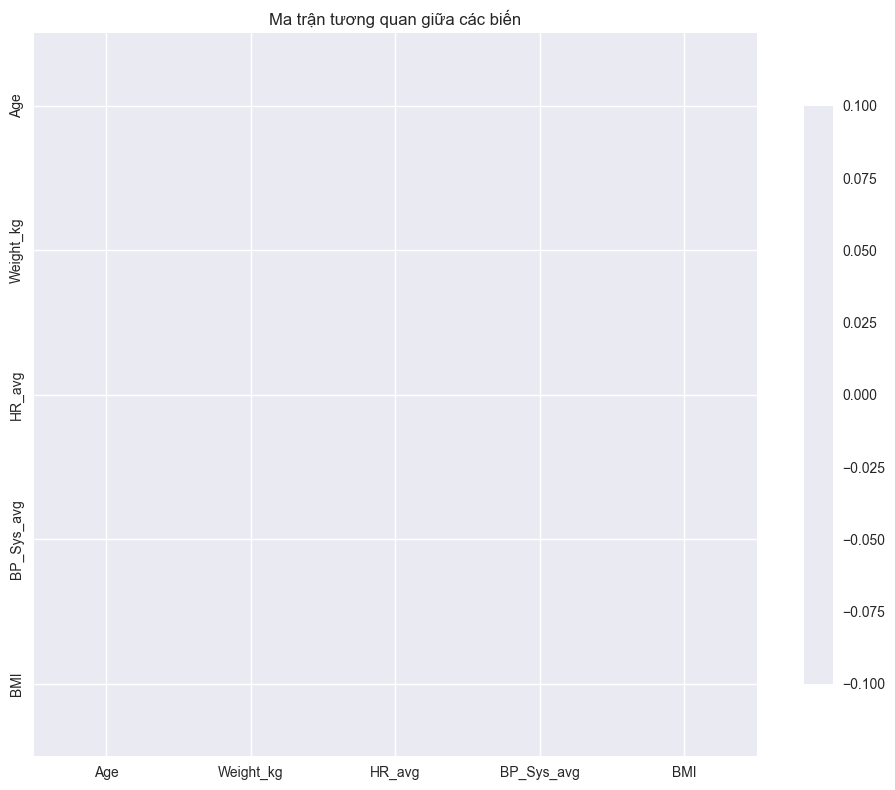

In [10]:
# Tạo ma trận tương quan
plt.figure(figsize=(10, 8))

# Chọn các cột số để tạo ma trận tương quan
correlation_columns = ['Age', 'Weight_kg', 'HR_avg', 'BP_Sys_avg', 'BMI']
correlation_data = df_clean[correlation_columns].dropna()

correlation_matrix = correlation_data.corr()

# Tạo heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Ma trận tương quan giữa các biến')
plt.tight_layout()
plt.show()


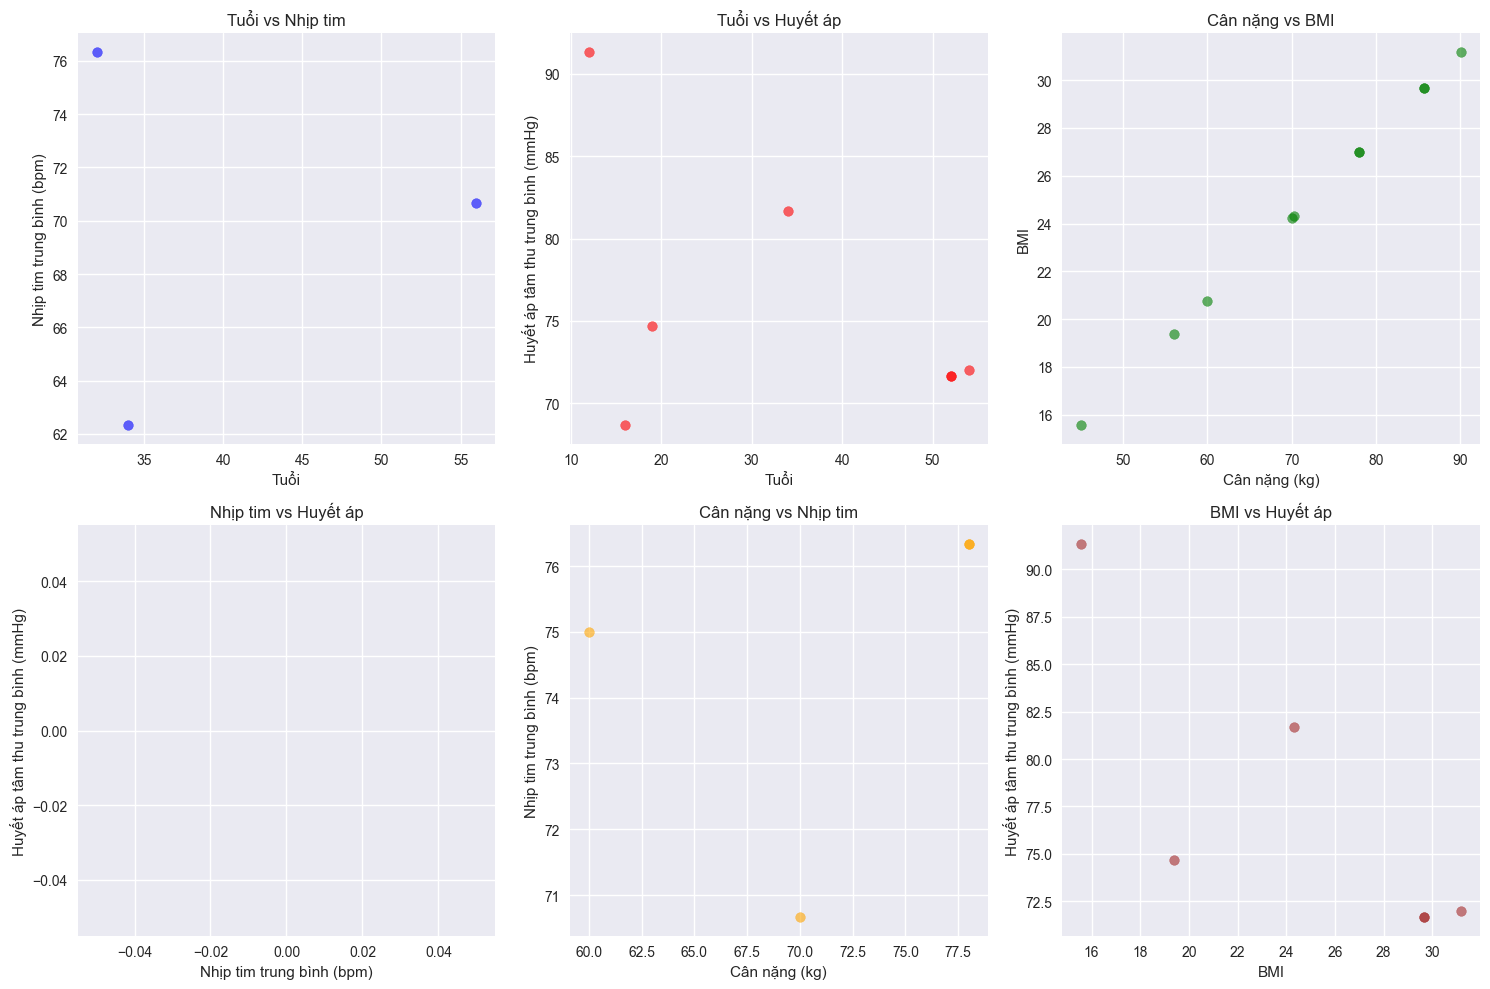

In [11]:
# Tạo scatter plot để xem mối quan hệ giữa các biến
plt.figure(figsize=(15, 10))

# Tuổi vs Nhịp tim
plt.subplot(2, 3, 1)
plt.scatter(df_clean['Age'], df_clean['HR_avg'], alpha=0.6, color='blue')
plt.xlabel('Tuổi')
plt.ylabel('Nhịp tim trung bình (bpm)')
plt.title('Tuổi vs Nhịp tim')

# Tuổi vs Huyết áp
plt.subplot(2, 3, 2)
plt.scatter(df_clean['Age'], df_clean['BP_Sys_avg'], alpha=0.6, color='red')
plt.xlabel('Tuổi')
plt.ylabel('Huyết áp tâm thu trung bình (mmHg)')
plt.title('Tuổi vs Huyết áp')

# Cân nặng vs BMI
plt.subplot(2, 3, 3)
plt.scatter(df_clean['Weight_kg'], df_clean['BMI'], alpha=0.6, color='green')
plt.xlabel('Cân nặng (kg)')
plt.ylabel('BMI')
plt.title('Cân nặng vs BMI')

# Nhịp tim vs Huyết áp
plt.subplot(2, 3, 4)
plt.scatter(df_clean['HR_avg'], df_clean['BP_Sys_avg'], alpha=0.6, color='purple')
plt.xlabel('Nhịp tim trung bình (bpm)')
plt.ylabel('Huyết áp tâm thu trung bình (mmHg)')
plt.title('Nhịp tim vs Huyết áp')

# Cân nặng vs Nhịp tim
plt.subplot(2, 3, 5)
plt.scatter(df_clean['Weight_kg'], df_clean['HR_avg'], alpha=0.6, color='orange')
plt.xlabel('Cân nặng (kg)')
plt.ylabel('Nhịp tim trung bình (bpm)')
plt.title('Cân nặng vs Nhịp tim')

# BMI vs Huyết áp
plt.subplot(2, 3, 6)
plt.scatter(df_clean['BMI'], df_clean['BP_Sys_avg'], alpha=0.6, color='brown')
plt.xlabel('BMI')
plt.ylabel('Huyết áp tâm thu trung bình (mmHg)')
plt.title('BMI vs Huyết áp')

plt.tight_layout()
plt.show()


## 4. Phân tích thống kê và insights


In [12]:
# Thống kê mô tả chi tiết
print("="*60)
print("THỐNG KÊ MÔ TẢ DỮ LIỆU BỆNH NHÂN")
print("="*60)

print(f"Tổng số bệnh nhân: {len(df_clean)}")
print(f"Số bệnh nhân có đầy đủ thông tin tuổi: {df_clean['Age'].notna().sum()}")
print(f"Số bệnh nhân có thông tin cân nặng: {df_clean['Weight_kg'].notna().sum()}")
print(f"Số bệnh nhân có thông tin nhịp tim: {df_clean['HR_avg'].notna().sum()}")
print(f"Số bệnh nhân có thông tin huyết áp: {df_clean['BP_Sys_avg'].notna().sum()}")

print("\n" + "="*60)
print("THỐNG KÊ TUỔI")
print("="*60)
age_stats = df_clean['Age'].describe()
print(age_stats)

print("\n" + "="*60)
print("THỐNG KÊ CÂN NẶNG")
print("="*60)
weight_stats = df_clean['Weight_kg'].describe()
print(weight_stats)

print("\n" + "="*60)
print("THỐNG KÊ NHỊP TIM")
print("="*60)
hr_stats = df_clean['HR_avg'].describe()
print(hr_stats)

print("\n" + "="*60)
print("THỐNG KÊ HUYẾT ÁP TÂM THU")
print("="*60)
bp_stats = df_clean['BP_Sys_avg'].describe()
print(bp_stats)


THỐNG KÊ MÔ TẢ DỮ LIỆU BỆNH NHÂN
Tổng số bệnh nhân: 14
Số bệnh nhân có đầy đủ thông tin tuổi: 10
Số bệnh nhân có thông tin cân nặng: 10
Số bệnh nhân có thông tin nhịp tim: 5
Số bệnh nhân có thông tin huyết áp: 8

THỐNG KÊ TUỔI
count    10.000000
mean     36.100000
std      16.749461
min      12.000000
25%      22.250000
50%      34.000000
75%      52.000000
max      56.000000
Name: Age, dtype: float64

THỐNG KÊ CÂN NẶNG
count    10.000000
mean     71.882432
std      14.578620
min      45.000000
25%      62.500000
50%      74.128432
75%      83.796666
max      90.109680
Name: Weight_kg, dtype: float64

THỐNG KÊ NHỊP TIM
count     5.000000
mean     72.133333
std       5.951657
min      62.333333
25%      70.666667
50%      75.000000
75%      76.333333
max      76.333333
Name: HR_avg, dtype: float64

THỐNG KÊ HUYẾT ÁP TÂM THU
count     8.000000
mean     75.208333
std       7.628138
min      68.666667
25%      71.250000
50%      71.833333
75%      76.416667
max      91.333333
Name: BP_Sys_

In [13]:
# Phân tích theo nhóm tuổi
print("="*60)
print("PHÂN TÍCH THEO NHÓM TUỔI")
print("="*60)

# Tạo nhóm tuổi
def categorize_age(age):
    if pd.isna(age):
        return 'Không xác định'
    elif age < 18:
        return 'Trẻ em (<18)'
    elif age < 30:
        return 'Thanh niên (18-29)'
    elif age < 50:
        return 'Trung niên (30-49)'
    elif age < 65:
        return 'Trung cao tuổi (50-64)'
    else:
        return 'Cao tuổi (≥65)'

df_clean['Age_Group'] = df_clean['Age'].apply(categorize_age)

# Thống kê theo nhóm tuổi
age_group_stats = df_clean.groupby('Age_Group').agg({
    'Age': 'count',
    'Weight_kg': ['mean', 'std'],
    'HR_avg': ['mean', 'std'],
    'BP_Sys_avg': ['mean', 'std']
}).round(2)

print("Thống kê theo nhóm tuổi:")
print(age_group_stats)


PHÂN TÍCH THEO NHÓM TUỔI
Thống kê theo nhóm tuổi:
                         Age Weight_kg        HR_avg       BP_Sys_avg       
                       count      mean    std   mean   std       mean    std
Age_Group                                                                   
Không xác định             0     69.00  12.73  75.67  0.94      70.00    NaN
Thanh niên (18-29)         1     56.00    NaN    NaN   NaN      74.67    NaN
Trung cao tuổi (50-64)     4     82.89   8.84  70.67   NaN      71.78   0.19
Trung niên (30-49)         3     74.13   5.48  69.33  9.90      81.67    NaN
Trẻ em (<18)               2     45.00    NaN    NaN   NaN      80.00  16.03


In [14]:
# Phân tích tình trạng sức khỏe
print("="*60)
print("PHÂN TÍCH TÌNH TRẠNG SỨC KHỎE")
print("="*60)

# Phân loại BMI
def categorize_bmi(bmi):
    if pd.isna(bmi):
        return 'Không xác định'
    elif bmi < 18.5:
        return 'Thiếu cân'
    elif bmi < 25:
        return 'Bình thường'
    elif bmi < 30:
        return 'Thừa cân'
    else:
        return 'Béo phì'

df_clean['BMI_Category'] = df_clean['BMI'].apply(categorize_bmi)

# Phân loại huyết áp
def categorize_bp(bp):
    if pd.isna(bp):
        return 'Không xác định'
    elif bp < 120:
        return 'Bình thường'
    elif bp < 140:
        return 'Tiền tăng huyết áp'
    else:
        return 'Tăng huyết áp'

df_clean['BP_Category'] = df_clean['BP_Sys_avg'].apply(categorize_bp)

# Phân loại nhịp tim
def categorize_hr(hr):
    if pd.isna(hr):
        return 'Không xác định'
    elif hr < 60:
        return 'Chậm'
    elif hr <= 100:
        return 'Bình thường'
    else:
        return 'Nhanh'

df_clean['HR_Category'] = df_clean['HR_avg'].apply(categorize_hr)

print("Phân bố BMI:")
print(df_clean['BMI_Category'].value_counts())
print("\nPhân bố huyết áp:")
print(df_clean['BP_Category'].value_counts())
print("\nPhân bố nhịp tim:")
print(df_clean['HR_Category'].value_counts())


PHÂN TÍCH TÌNH TRẠNG SỨC KHỎE
Phân bố BMI:
BMI_Category
Bình thường       4
Không xác định    4
Thừa cân          4
Béo phì           1
Thiếu cân         1
Name: count, dtype: int64

Phân bố huyết áp:
BP_Category
Bình thường       8
Không xác định    6
Name: count, dtype: int64

Phân bố nhịp tim:
HR_Category
Không xác định    9
Bình thường       5
Name: count, dtype: int64


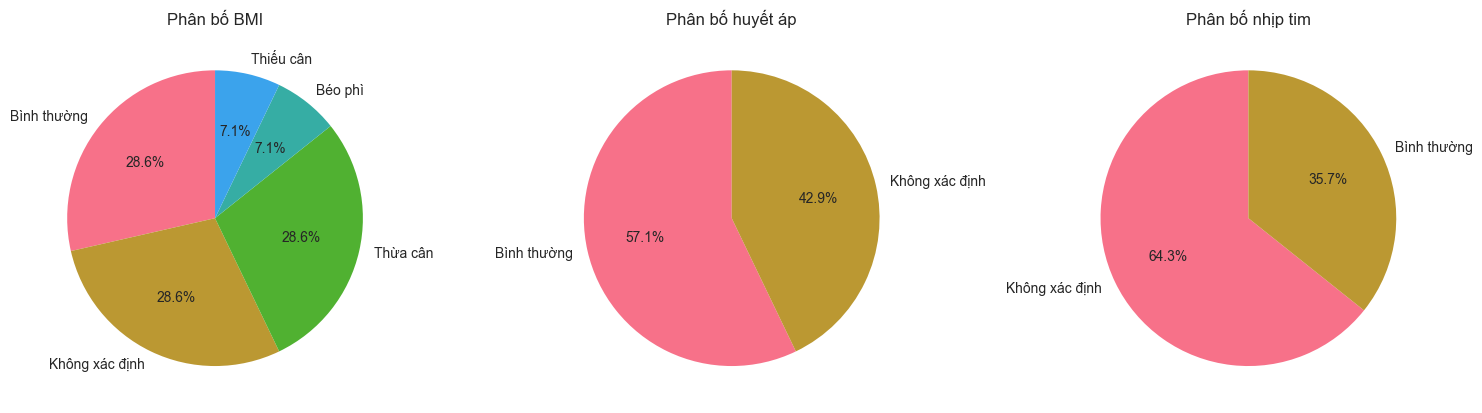

In [15]:
# Tạo biểu đồ phân bố tình trạng sức khỏe
plt.figure(figsize=(15, 5))

# Biểu đồ BMI
plt.subplot(1, 3, 1)
bmi_counts = df_clean['BMI_Category'].value_counts()
plt.pie(bmi_counts.values, labels=bmi_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Phân bố BMI')

# Biểu đồ huyết áp
plt.subplot(1, 3, 2)
bp_counts = df_clean['BP_Category'].value_counts()
plt.pie(bp_counts.values, labels=bp_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Phân bố huyết áp')

# Biểu đồ nhịp tim
plt.subplot(1, 3, 3)
hr_counts = df_clean['HR_Category'].value_counts()
plt.pie(hr_counts.values, labels=hr_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Phân bố nhịp tim')

plt.tight_layout()
plt.show()


In [16]:
# Tìm các trường hợp bất thường
print("="*60)
print("PHÂN TÍCH CÁC TRƯỜNG HỢP BẤT THƯỜNG")
print("="*60)

# Bệnh nhân có huyết áp cao
high_bp = df_clean[df_clean['BP_Sys_avg'] > 140]
print(f"Số bệnh nhân có huyết áp cao (>140 mmHg): {len(high_bp)}")
if len(high_bp) > 0:
    print("Danh sách bệnh nhân có huyết áp cao:")
    print(high_bp[['Name', 'Age', 'BP_Sys_avg']].to_string(index=False))

print("\n" + "-"*40)

# Bệnh nhân có nhịp tim bất thường
abnormal_hr = df_clean[(df_clean['HR_avg'] < 60) | (df_clean['HR_avg'] > 100)]
print(f"Số bệnh nhân có nhịp tim bất thường (<60 hoặc >100 bpm): {len(abnormal_hr)}")
if len(abnormal_hr) > 0:
    print("Danh sách bệnh nhân có nhịp tim bất thường:")
    print(abnormal_hr[['Name', 'Age', 'HR_avg']].to_string(index=False))

print("\n" + "-"*40)

# Bệnh nhân có BMI bất thường
abnormal_bmi = df_clean[(df_clean['BMI'] < 18.5) | (df_clean['BMI'] > 30)]
print(f"Số bệnh nhân có BMI bất thường (<18.5 hoặc >30): {len(abnormal_bmi)}")
if len(abnormal_bmi) > 0:
    print("Danh sách bệnh nhân có BMI bất thường:")
    print(abnormal_bmi[['Name', 'Age', 'BMI', 'BMI_Category']].to_string(index=False))


PHÂN TÍCH CÁC TRƯỜNG HỢP BẤT THƯỜNG
Số bệnh nhân có huyết áp cao (>140 mmHg): 0

----------------------------------------
Số bệnh nhân có nhịp tim bất thường (<60 hoặc >100 bpm): 0

----------------------------------------
Số bệnh nhân có BMI bất thường (<18.5 hoặc >30): 2
Danh sách bệnh nhân có BMI bất thường:
        Name  Age       BMI BMI_Category
Pink Panther 54.0 31.179820      Béo phì
Louie McDuck 12.0 15.570934    Thiếu cân


## 5. Kết luận và Khuyến nghị


In [17]:
# Tổng kết phân tích
print("="*80)
print("TỔNG KẾT PHÂN TÍCH DỮ LIỆU BỆNH NHÂN")
print("="*80)

print("\n1. THÔNG TIN TỔNG QUAN:")
print(f"   - Tổng số bệnh nhân: {len(df_clean)}")
print(f"   - Độ tuổi trung bình: {df_clean['Age'].mean():.1f} tuổi")
print(f"   - Cân nặng trung bình: {df_clean['Weight_kg'].mean():.1f} kg")
print(f"   - Nhịp tim trung bình: {df_clean['HR_avg'].mean():.1f} bpm")
print(f"   - Huyết áp tâm thu trung bình: {df_clean['BP_Sys_avg'].mean():.1f} mmHg")

print("\n2. TÌNH TRẠNG SỨC KHỎE:")
print(f"   - Tỷ lệ bệnh nhân có huyết áp bình thường: {(df_clean['BP_Category'] == 'Bình thường').sum() / len(df_clean) * 100:.1f}%")
print(f"   - Tỷ lệ bệnh nhân có nhịp tim bình thường: {(df_clean['HR_Category'] == 'Bình thường').sum() / len(df_clean) * 100:.1f}%")
print(f"   - Tỷ lệ bệnh nhân có BMI bình thường: {(df_clean['BMI_Category'] == 'Bình thường').sum() / len(df_clean) * 100:.1f}%")

print("\n3. CÁC VẤN ĐỀ CẦN CHÚ Ý:")
high_bp_count = (df_clean['BP_Sys_avg'] > 140).sum()
abnormal_hr_count = ((df_clean['HR_avg'] < 60) | (df_clean['HR_avg'] > 100)).sum()
abnormal_bmi_count = ((df_clean['BMI'] < 18.5) | (df_clean['BMI'] > 30)).sum()

print(f"   - Số bệnh nhân có huyết áp cao: {high_bp_count}")
print(f"   - Số bệnh nhân có nhịp tim bất thường: {abnormal_hr_count}")
print(f"   - Số bệnh nhân có BMI bất thường: {abnormal_bmi_count}")

print("\n4. MỐI QUAN HỆ GIỮA CÁC BIẾN:")
correlation_age_hr = df_clean[['Age', 'HR_avg']].corr().iloc[0,1]
correlation_age_bp = df_clean[['Age', 'BP_Sys_avg']].corr().iloc[0,1]
correlation_weight_bp = df_clean[['Weight_kg', 'BP_Sys_avg']].corr().iloc[0,1]

print(f"   - Tương quan giữa tuổi và nhịp tim: {correlation_age_hr:.3f}")
print(f"   - Tương quan giữa tuổi và huyết áp: {correlation_age_bp:.3f}")
print(f"   - Tương quan giữa cân nặng và huyết áp: {correlation_weight_bp:.3f}")


TỔNG KẾT PHÂN TÍCH DỮ LIỆU BỆNH NHÂN

1. THÔNG TIN TỔNG QUAN:
   - Tổng số bệnh nhân: 14
   - Độ tuổi trung bình: 36.1 tuổi
   - Cân nặng trung bình: 71.9 kg
   - Nhịp tim trung bình: 72.1 bpm
   - Huyết áp tâm thu trung bình: 75.2 mmHg

2. TÌNH TRẠNG SỨC KHỎE:
   - Tỷ lệ bệnh nhân có huyết áp bình thường: 57.1%
   - Tỷ lệ bệnh nhân có nhịp tim bình thường: 35.7%
   - Tỷ lệ bệnh nhân có BMI bình thường: 28.6%

3. CÁC VẤN ĐỀ CẦN CHÚ Ý:
   - Số bệnh nhân có huyết áp cao: 0
   - Số bệnh nhân có nhịp tim bất thường: 0
   - Số bệnh nhân có BMI bất thường: 2

4. MỐI QUAN HỆ GIỮA CÁC BIẾN:
   - Tương quan giữa tuổi và nhịp tim: 0.034
   - Tương quan giữa tuổi và huyết áp: -0.476
   - Tương quan giữa cân nặng và huyết áp: -0.815


### Khuyến nghị:

1. **Theo dõi sức khỏe định kỳ**: Các bệnh nhân có chỉ số bất thường cần được theo dõi thường xuyên hơn.

2. **Tư vấn lối sống**: 
   - Bệnh nhân có BMI cao nên được tư vấn về chế độ ăn uống và tập luyện
   - Bệnh nhân có huyết áp cao cần được hướng dẫn về chế độ ăn ít muối

3. **Cải thiện chất lượng dữ liệu**: 
   - Cần thu thập thêm thông tin về chiều cao để tính BMI chính xác
   - Cần đo huyết áp tâm trương để có đánh giá toàn diện hơn

4. **Phân tích sâu hơn**: 
   - Có thể phân tích theo giới tính nếu có dữ liệu
   - Theo dõi xu hướng thay đổi theo thời gian


In [18]:
# Lưu dữ liệu đã xử lý
df_clean.to_csv('patient_heart_rate_cleaned.csv', index=False, encoding='utf-8')
print("Đã lưu dữ liệu đã xử lý vào file 'patient_heart_rate_cleaned.csv'")

# Hiển thị thông tin cuối cùng
print("\n" + "="*60)
print("THÔNG TIN FILE ĐÃ TẠO")
print("="*60)
print("File gốc: patient_heart_rate.csv")
print("File đã xử lý: patient_heart_rate_cleaned.csv")
print("Notebook phân tích: Lab4_Patient_HeartRate_Analysis.ipynb")
print("\nPhân tích hoàn tất!")


Đã lưu dữ liệu đã xử lý vào file 'patient_heart_rate_cleaned.csv'

THÔNG TIN FILE ĐÃ TẠO
File gốc: patient_heart_rate.csv
File đã xử lý: patient_heart_rate_cleaned.csv
Notebook phân tích: Lab4_Patient_HeartRate_Analysis.ipynb

Phân tích hoàn tất!
